Things I have to add for numerical data

- ~~'BOX PLOT'~~
- ~~'DENSITY_PLOT'~~
- ~~'CONNECTED_SCATTER PLOT'~~
- '3D_SCATTEROR_SURFACE'
- 'PCA'
- 'RIDGE_LINE'
- 'DENDROGRAM'
- 'SCATTER_WITH_MARGINAL_POINT'
- 'BOX_PLOT'
- ~~'SCATTER_PLOT'~~
- 'STACKED_AREA_PLOT'
- ~~'VIOLIN_PLOT'~~
- 'AREA(SM)'
- 'STREAM_GRAPH'
- 'LINE_PLOT'
- 'BUBBLE_PLOT'
- '2D_DENSITY_PLOT'
- 'HISTOGRAM'
- 'AREA_PLOT'
- 'CORRELOGRAM'
- 'HEATMAP'


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [16]:

class ConnectedScatterPlot:
    def __init__(
        self,
        df,
        x=None,
        y=None,
        plots=None,
        ax=None,
        title=None,
        default_style=None,
        **kwargs
    ):
        """
        This is used to create one or more connected scatter plots using matplotlib.

        Parameters:
        -----------
        df (pandas.DataFrame):
            The data to plot. DataFrame preferred.
        x, y (str or array-like, optional):
            Variables to use for a basic single plot.
        plots (list of dict, optional):
            List of dictionaries where each dictionary contains parameters for individual plots.
        ax (matplotlib.axes.Axes, optional):
            Pre-existing axes for the plot. Otherwise, a new one is created.
        title (str, optional):
            Title for the plot.
        default_style (dict, optional):
            Default styling options for the plots like 'linestyle', 'marker', 'color', etc.
        **kwargs:
            Additional keyword arguments passed to the underlying `plot` function for default style.

        Each dictionary in `plots` should contain:
            - 'x': Column name or array-like for x-axis data.
            - 'y': Column name or array-like for y-axis data.
            - 'linestyle': Style of the line connecting data points.
            - 'marker': Style of the markers on data points.
            - 'color': Color for the line and markers.
            - 'linewidth': Width of the lines connecting points.
            - 'label': Label for the plot (optional for legend).

        Return:
        -------
        None
        """
        self.__df = df
        self.__plots = plots or []
        self.__ax = ax
        self.__title = title
        self.__default_style = default_style or {}

        if x and y:
            # If x and y are provided for a basic single plot
            self.__plots = [{"x": x, "y": y, **self.__default_style, **kwargs}]

        self.__plot()

    def __plot(self):
        """
        This is a private method used to create the connected scatter plots.
        """
        if self.__ax is None:
            self.__ax = plt.gca()

        for plot in self.__plots:
            # Extract x and y to use as positional arguments
            x = plot.pop("x")
            y = plot.pop("y")

            # Pass the rest of the dictionary as keyword arguments
            self.__ax.plot(self.__df[x], self.__df[y], **plot)

        if self.__title:
            self.__ax.set_title(self.__title)

        self.__ax.legend()

    def save_plot(self, file_name, folder=None, size=(10, 6)):
        """
        This method saves the created plot in the specified directory.

        Args:
            file_name (str): Name of the file
            folder (str, optional): Name of the directory. If not available, it creates one.
            size (tuple, optional): Size of the figure in inches (width, height). Default is (10, 6).

        """
        if folder:
            if not os.path.exists(folder):
                os.makedirs(folder)
            file_name = os.path.join(folder, file_name)

        fig, ax = plt.subplots(figsize=size)
        self.__ax = ax  # Use the new axis for plotting
        self.__plot()
        plt.savefig(file_name)
        plt.close(fig)  # prevent figure from popping up in the notebook
        plt.ion()  # turns the display of the plot back on

In [17]:

df = sns.load_dataset('iris')

In [18]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [19]:
df = pd.DataFrame({
    'x_axis': range(1,10),
    'y_axis': np.random.randn(9)*80+range(1,10)
})

C:\Users\user\AppData\Local\Temp\ipykernel_11744\1283886572.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.__ax.legend()


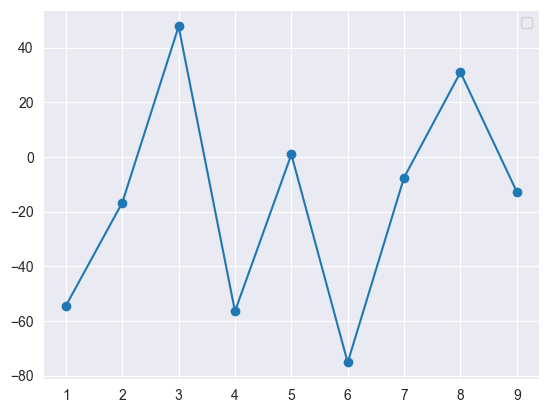

In [21]:
df["other_column"] = np.random.choice(['A', 'B', 'C', 'D'], size=len(df))

vp = ConnectedScatterPlot(
    x="x_axis",
    y="y_axis",
    df=df,
    linestyle="-",
    marker="o",
)

In [6]:
vp.save_plot('violin_plot.png', size=(10, 10))